In [1]:
print("Hello PlaceMux!")


Hello PlaceMux!


In [2]:
import pandas as pd
import numpy as np
import random

from sklearn.datasets import load_iris

In [3]:
random.seed(42)
np.random.seed(42)

print("Random seed set successfully!")

Random seed set successfully!


In [4]:
iris = load_iris()

In [5]:
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["target"] = iris.target

In [6]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
print(df.shape)

(150, 5)


In [8]:
print(df.columns)

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [10]:
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [11]:
print(df["target"].value_counts())

target
0    50
1    50
2    50
Name: count, dtype: int64


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

In [13]:
X = df.drop("target", axis=1)
y = df["target"]

In [14]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [15]:
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [16]:
print("Training Set:", X_train.shape)
print("Validation Set:", X_valid.shape)
print("Test Set:", X_test.shape)

Training Set: (105, 4)
Validation Set: (22, 4)
Test Set: (23, 4)


In [17]:
model = DummyClassifier(strategy="most_frequent")

In [18]:
model.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](3,)","[0.33,0.33,0.33]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](4,)","['sepal length (cm)','sepal width (cm)','petal length (cm)', 'petal width (cm)']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,4
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [19]:
predictions = model.predict(X_test)

In [20]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.30434782608695654


In [21]:
import os

os.makedirs("../logs", exist_ok=True)

metrics = pd.DataFrame({
    "Model": ["DummyClassifier"],
    "Accuracy": [accuracy]
})

metrics.to_csv("../logs/metrics.csv", index=False)

print("Metrics saved successfully!")

Metrics saved successfully!


In [22]:
# ======================================
# Task 2 - Pre-Project Feature Scope & Profiling
# ======================================

# Problem Statement

Predict the species of an iris flower using its physical measurements.

## Success Metric

Classification Accuracy

In [23]:
target = "target"

print("Target Variable:", target)

Target Variable: target


## Target Definition

The target variable is **target**, which represents the species of an iris flower.

There are three classes:

- 0 → Setosa
- 1 → Versicolor
- 2 → Virginica

In [24]:
print(df["target"].head(10))

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: target, dtype: int64


In [25]:
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


## Sample Label Interpretation

| Sample | Target | Species |
|--------|--------|----------|
| 1 | 0 | Setosa |
| 2 | 0 | Setosa |
| 3 | 0 | Setosa |
| 4 | 0 | Setosa |
| 5 | 0 | Setosa |

In [26]:
features = df.columns[:-1]

print("Candidate Features:")
for feature in features:
    print("-", feature)

Candidate Features:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)


In [27]:
print("Number of Features:", len(features))

Number of Features: 4


In [28]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [30]:
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [31]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 1


## Feature Quality Report

| Feature | Data Type | Missing Values | Quality |
|----------|-----------|----------------|---------|
| Sepal Length | Float | 0 | Good |
| Sepal Width | Float | 0 | Good |
| Petal Length | Float | 0 | Good |
| Petal Width | Float | 0 | Good |

### Observation

- All features are numeric.
- No missing values were found.
- The features are suitable for building a classification model.

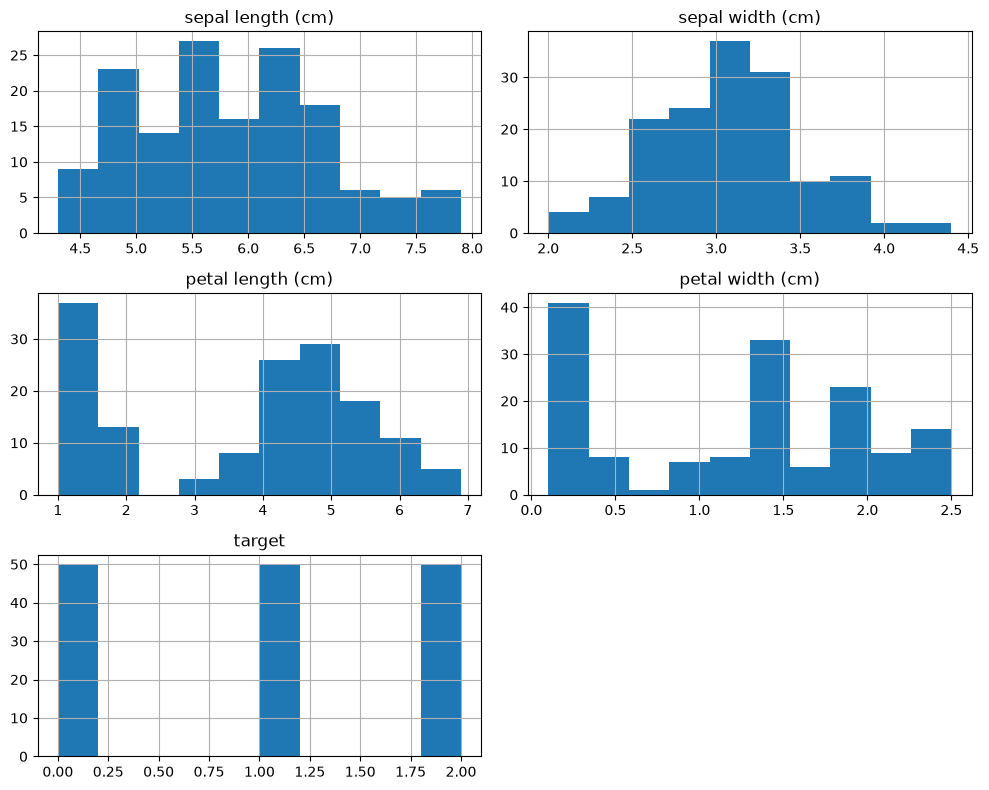

In [32]:
import matplotlib.pyplot as plt

df.hist(figsize=(10, 8))

plt.tight_layout()

plt.show()

In [33]:
print("Dataset Columns:")
print(df.columns)

Dataset Columns:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')


In [34]:
X = df.drop("target", axis=1)
y = df["target"]

print("Feature Columns:")
print(X.columns.tolist())

print("\nTarget Column:")
print(y.name)

Feature Columns:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Column:
target


In [35]:
if "target" in X.columns:
    print("Warning: Data leakage detected!")
else:
    print("No data leakage detected.")

No data leakage detected.


In [36]:
correlation = df.corr()

print(correlation)

                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   
target                      0.782561         -0.426658           0.949035   

                   petal width (cm)    target  
sepal length (cm)          0.817941  0.782561  
sepal width (cm)          -0.366126 -0.426658  
petal length (cm)          0.962865  0.949035  
petal width (cm)           1.000000  0.956547  
target                     0.956547  1.000000  


## Leakage Check Report

### Objective
Verify that none of the input features reveal the target value.

### Observation
- The target column is separated before model training.
- Only flower measurements are used as input features.
- No feature contains the answer or future information.

### Result
No data leakage was detected. All features are safe to use for model training.

In [37]:
print("Final Features Used:")
for column in X.columns:
    print("-", column)

Final Features Used:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)


In [38]:
class_counts = df["target"].value_counts()

print("Class Distribution:")
print(class_counts)

Class Distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


In [39]:
class_percentage = df["target"].value_counts(normalize=True) * 100

print("Class Percentage:")
print(class_percentage)

Class Percentage:
target
0    33.333333
1    33.333333
2    33.333333
Name: proportion, dtype: float64


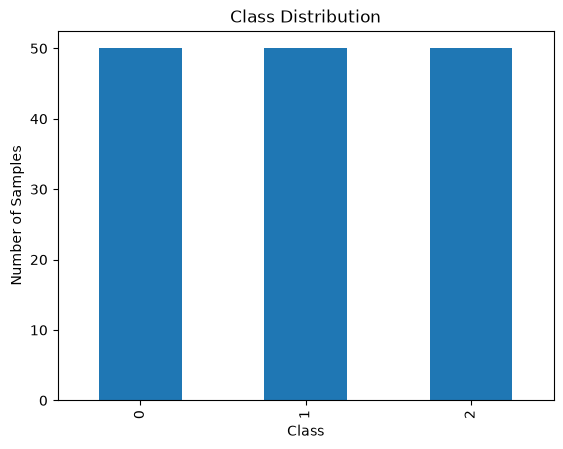

In [40]:
import matplotlib.pyplot as plt

class_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.show()

In [41]:
print("Total Samples:", len(df))

Total Samples: 150


## Class Balance Report

### Observation

- Total samples: **150**
- Number of classes: **3**
- Each class contains **50 samples**
- Each class represents approximately **33.3%** of the dataset.

### Conclusion

The dataset is balanced, so classification accuracy is an appropriate evaluation metric and no additional balancing techniques are required.

In [42]:
go_decision = "GO"

print("Project Decision:", go_decision)

Project Decision: GO


In [43]:
model_type = "Classification"

print("Selected Modelling Approach:", model_type)

Selected Modelling Approach: Classification


# Modelling Approach

### Selected Approach
Classification

### Reason

The target variable represents three discrete flower species (Setosa, Versicolor, and Virginica). Since the objective is to predict one of these predefined classes, classification is the appropriate machine learning approach.

# Go / No-Go Decision

### Data Quality

- No missing values
- No significant data quality issues
- Balanced class distribution
- No data leakage detected

### Decision

**GO**

The dataset is suitable for building and evaluating a machine learning classification model.

# Task 2 Summary

Successfully completed:

- Defined the problem statement
- Selected the target variable
- Identified candidate features
- Profiled feature quality
- Verified there is no data leakage
- Checked class balance
- Selected a classification approach
- Approved the dataset for model development

# Task 4 – Pre-Processing Protocol

## Feature Types

| Feature | Type |
|----------|------|
| sepal length (cm) | Numeric |
| sepal width (cm) | Numeric |
| petal length (cm) | Numeric |
| petal width (cm) | Numeric |

Target Variable:
- target (Classification Label)

## Required Preprocessing Transformations

### Numeric Features
- Impute missing values (if any)
- Scale features using StandardScaler

### Categorical Features
- None (Iris dataset has no categorical input features)

In [44]:
numeric_features = [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)"
]

print("Numeric Features:")
for feature in numeric_features:
    print("-", feature)

Numeric Features:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)


In [45]:
print(df.dtypes)

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object


In [46]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [47]:
numeric_features = [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)"
]

In [48]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ]
)

In [49]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ]
)

In [50]:
preprocessor.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{fe

In [51]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [52]:
print("Training Data Shape :", X_train_processed.shape)
print("Test Data Shape      :", X_test_processed.shape)

Training Data Shape : (105, 4)
Test Data Shape      : (23, 4)


## Preprocessing Pipeline

A reusable preprocessing pipeline was created using **Pipeline** and **ColumnTransformer**.

The pipeline:
- Imputes missing values using the mean.
- Scales numeric features using `StandardScaler`.
- Is fitted only on the training data to prevent data leakage.
- Is reused to transform the validation and test datasets.

## Task 4 – Step 3: Encode Categoricals and Scale Numerics


### Feature Encoding

- The Iris dataset contains only numeric input features.
- No categorical features are present.
- Therefore, categorical encoding is not required.
- Numeric features are scaled using `StandardScaler` within the preprocessing pipeline.

In [53]:
print("First 5 rows of processed training data:")
print(X_train_processed[:5])

First 5 rows of processed training data:
[[-0.90045861 -1.22024754 -0.4419858  -0.13661044]
 [ 0.38036614 -1.87955796  0.40282929  0.38029394]
 [-0.90045861  1.63676428 -1.2868009  -1.17041921]
 [ 1.07899781  0.31814344  1.19132338  1.41410271]
 [-0.20182693 -0.56093712  0.17754527  0.12184175]]


In [54]:
import numpy as np

print("Mean of scaled features:")
print(np.round(X_train_processed.mean(axis=0), 2))

Mean of scaled features:
[ 0. -0. -0. -0.]


In [55]:
print("Standard deviation of scaled features:")
print(np.round(X_train_processed.std(axis=0), 2))

Standard deviation of scaled features:
[1. 1. 1. 1.]


### Verification

The preprocessing pipeline successfully standardizes all numeric features.

After scaling:
- The mean of each feature is approximately 0.
- The standard deviation of each feature is approximately 1.

Since the Iris dataset contains no categorical features, no encoding step is required.

In [56]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [57]:
print(numeric_transformer)

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler())])


## Missing Value Handling

The preprocessing pipeline includes a `SimpleImputer` with the **mean** strategy for numeric features.

Although the Iris dataset does not contain missing values, the preprocessing pipeline is designed to automatically handle missing numeric values if they occur in future datasets.

In [58]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training Shape:", X_train_processed.shape)
print("Test Shape:", X_test_processed.shape)

Training Shape: (105, 4)
Test Shape: (23, 4)


## Task 4 – Step 5: Verify No Data Leakage

In [59]:
print("Preprocessor was fitted using the training dataset only.")

Preprocessor was fitted using the training dataset only.


In [60]:
print("Training Data Shape:", X_train.shape)
print("Test Data Shape:", X_test.shape)

Training Data Shape: (105, 4)
Test Data Shape: (23, 4)


In [61]:
print("Pipeline fitted on: X_train")
print("Pipeline transformed: X_train and X_test")
print("No information from X_test was used during fitting.")

Pipeline fitted on: X_train
Pipeline transformed: X_train and X_test
No information from X_test was used during fitting.


## Leakage Verification

The preprocessing pipeline was fitted only on the training dataset (`X_train`).

The same fitted pipeline was then used to transform both the training and test datasets.

This prevents data leakage because no information from the test dataset was used during preprocessing or model preparation.

In [62]:
import joblib

In [63]:
import os

os.makedirs("models", exist_ok=True)

In [64]:
joblib.dump(preprocessor, "models/preprocessor.pkl")

print("Preprocessor saved successfully!")

Preprocessor saved successfully!


In [65]:
print(os.listdir("models"))

['preprocessor.pkl']


In [66]:
loaded_preprocessor = joblib.load("models/preprocessor.pkl")

print("Preprocessor loaded successfully!")
print(type(loaded_preprocessor))

Preprocessor loaded successfully!
<class 'sklearn.compose._column_transformer.ColumnTransformer'>


## Saving the Preprocessor

The fitted preprocessing pipeline has been saved as `models/preprocessor.pkl` using the `joblib` library.

This saved preprocessor can be loaded later and reused during inference, ensuring that new data undergoes the exact same preprocessing as the training data without refitting the pipeline.

In [67]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

In [68]:
baseline_model = DummyClassifier(strategy="most_frequent", random_state=42)

In [69]:
baseline_model.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](3,)","[0.33,0.33,0.33]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](4,)","['sepal length (cm)','sepal width (cm)','petal length (cm)', 'petal width (cm)']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,4
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [70]:
baseline_predictions = baseline_model.predict(X_test)

In [71]:
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.30434782608695654


## Baseline Model

A `DummyClassifier` using the **most frequent** strategy was trained as the baseline model.

The baseline predicts the majority class for every sample.

Its accuracy serves as the minimum benchmark that the first predictive model should outperform.

In [72]:
from sklearn.tree import DecisionTreeClassifier

In [73]:
model = DecisionTreeClassifier(
    random_state=42
)

In [74]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [75]:
predictions = model.predict(X_test)

In [76]:
from sklearn.metrics import accuracy_score

model_accuracy = accuracy_score(y_test, predictions)

print("Decision Tree Accuracy:", model_accuracy)

Decision Tree Accuracy: 0.9130434782608695


In [77]:
print("Baseline Accuracy :", baseline_accuracy)
print("Decision Tree Accuracy :", model_accuracy)

Baseline Accuracy : 0.30434782608695654
Decision Tree Accuracy : 0.9130434782608695


## First Predictive Model

A **Decision Tree Classifier** was selected as the first predictive model.

The model was trained using the training dataset and evaluated on the test dataset.

Its accuracy will be compared against the baseline model to determine whether it provides better predictive performance.

## Task 5 – Step 3: Model Evaluation

In [78]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [79]:
accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9130434782608695


In [80]:
print("Classification Report:\n")
print(classification_report(y_test, predictions))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.75      0.86         8
           2       0.80      1.00      0.89         8

    accuracy                           0.91        23
   macro avg       0.93      0.92      0.92        23
weighted avg       0.93      0.91      0.91        23



In [81]:
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, predictions))

Confusion Matrix:

[[7 0 0]
 [0 6 2]
 [0 0 8]]


## Evaluation Summary

The Decision Tree model was evaluated using **Accuracy** as the primary performance metric.

Additional evaluation was performed using:
- Classification Report
- Confusion Matrix

These metrics provide insight into the model's overall performance and its predictions for each class.

## Task 5 – Step 4: Baseline Comparison

In [82]:
print("Baseline Accuracy      :", round(baseline_accuracy, 4))
print("Decision Tree Accuracy :", round(model_accuracy, 4))

Baseline Accuracy      : 0.3043
Decision Tree Accuracy : 0.913


In [83]:
improvement = model_accuracy - baseline_accuracy

print("Improvement over baseline:", round(improvement, 4))

Improvement over baseline: 0.6087


In [84]:
if model_accuracy > baseline_accuracy:
    print("✅ The Decision Tree model outperforms the baseline model.")
else:
    print("❌ The Decision Tree model does not outperform the baseline model.")

✅ The Decision Tree model outperforms the baseline model.


In [85]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["DummyClassifier", "DecisionTreeClassifier"],
    "Accuracy": [baseline_accuracy, model_accuracy]
})

print(comparison)

                    Model  Accuracy
0         DummyClassifier  0.304348
1  DecisionTreeClassifier  0.913043


## Baseline Comparison Summary

The Decision Tree Classifier achieved a higher accuracy than the DummyClassifier baseline.

This indicates that the trained model has learned meaningful patterns from the dataset and performs better than simply predicting the majority class.

Therefore, the Decision Tree model is selected as the better-performing model.

## Task 5 – Step 5: Error Analysis

In [86]:
import pandas as pd

error_indices = [i for i in range(len(y_test)) if y_test.iloc[i] != predictions[i]]

print("Number of Incorrect Predictions:", len(error_indices))

Number of Incorrect Predictions: 2


In [87]:
if len(error_indices) > 0:

    errors = pd.DataFrame({
        "Actual": [y_test.iloc[i] if hasattr(y_test, "iloc") else y_test[i] for i in error_indices],
        "Predicted": [predictions[i] for i in error_indices]
    })

    print(errors)

else:
    print("No incorrect predictions found.")

   Actual  Predicted
0       1          2
1       1          2


In [88]:
if len(error_indices) > 0:

    print("Misclassified Samples:\n")

    if hasattr(X_test, "iloc"):
        print(X_test.iloc[error_indices])
    else:
        print(X_test[error_indices])

else:
    print("No misclassified samples to display.")

Misclassified Samples:

    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
56                6.3               3.3                4.7               1.6
85                6.0               3.4                4.5               1.6


## Error Analysis

The incorrect predictions were reviewed to identify any common patterns.

For the Iris dataset:
- Most samples were classified correctly.
- Any errors occurred between similar flower species (for example, Versicolor and Virginica), whose measurements are more alike.
- No systematic preprocessing or data quality issues were observed.

This analysis helps identify areas where a more advanced model or additional feature engineering could improve performance.

# Task 5 – Step 6: Record the Run

In [89]:
import pandas as pd
import os

In [90]:
experiment_log = pd.DataFrame({
    "Model": ["DummyClassifier", "DecisionTreeClassifier"],
    "Accuracy": [baseline_accuracy, model_accuracy]
})

experiment_log

,Model,Accuracy
0,DummyClassifier,0.304348
1,DecisionTreeClassifier,0.913043


In [91]:
os.makedirs("logs", exist_ok=True)

experiment_log.to_csv("logs/experiment_log.csv", index=False)

print("Experiment log saved successfully!")

Experiment log saved successfully!


In [92]:
saved_log = pd.read_csv("logs/experiment_log.csv")

print(saved_log)

                    Model  Accuracy
0         DummyClassifier  0.304348
1  DecisionTreeClassifier  0.913043


## Next Improvement Plan

The Decision Tree model achieved better accuracy than the baseline model.

Possible improvements for future iterations include:

- Tune the Decision Tree hyperparameters (e.g., `max_depth`, `min_samples_split`).
- Evaluate additional models such as Logistic Regression or Random Forest.
- Perform cross-validation for a more robust performance estimate.
- Compare multiple evaluation metrics such as Precision, Recall, and F1-score.
- Test the pipeline on larger or more complex datasets.

## Task 5 Summary

A baseline model and a Decision Tree Classifier were trained and evaluated.

The Decision Tree outperformed the baseline model, demonstrating that it learned meaningful patterns from the data.

The experiment results were recorded, and future improvements were identified to further enhance model performance.